# 06 — Multi-Model Comparison

Benchmarks additional classifiers and anomaly detectors against BehaviorDNA's current models
using the same train/val/test splits.

**Identification (multi-class player recognition):**

| Model | Notes |
|---|---|
| LightGBM | Current production model |
| RandomForest | Ensemble, no boosting |
| XGBoost | Gradient boosting, different regularisation |
| SVC (RBF) | Kernel SVM, strong on small datasets |

**Detection (bot / anomaly scoring, unsupervised):**

| Model | Notes |
|---|---|
| IsolationForest | Current production model |
| LocalOutlierFactor | Density-based, novelty=True |
| One-Class SVM | Kernel boundary around normal behaviour |

**Setup — imports.**
Loads all classifiers (`LightGBM`, `RandomForest`, `XGBoost`, `SVC`) and anomaly detectors (`IsolationForest`, `LocalOutlierFactor`, `OneClassSVM`). Also imports evaluation metrics (`accuracy_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`) and timing utilities. `FEATURE_COLS` is imported from the pipeline.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC, OneClassSVM
from xgboost import XGBClassifier

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.features.run import FEATURE_COLS

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SPLITS = ROOT / "data" / "splits"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

**Load splits and prepare feature matrices.**
Reads the train/val/test Parquet splits from `data/splits/`, combines train+val for final fitting (standard practice: use all non-test data before final evaluation), and applies `StandardScaler` (zero-mean / unit-variance normalisation). `LabelEncoder` converts player names to 0-indexed integers for sklearn compatibility.

**Findings:** Train+val = 42 windows, test = 17 windows, 4 players. With only 17 test windows, one misclassified window shifts accuracy by ~6 percentage points — metric variance is high until more data is collected.

In [2]:
train_df = pd.read_parquet(SPLITS / "train.parquet")
val_df   = pd.read_parquet(SPLITS / "val.parquet")
test_df  = pd.read_parquet(SPLITS / "test.parquet")

print(f"Train: {len(train_df)} windows, {train_df['player'].nunique()} players")
print(f"Val  : {len(val_df)} windows")
print(f"Test : {len(test_df)} windows")

# Combine train+val for final fit before test evaluation
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

def prep(df):
    return df[FEATURE_COLS].fillna(0.0).values

scaler = StandardScaler()
X_train = scaler.fit_transform(prep(trainval_df))
X_test  = scaler.transform(prep(test_df))

le = LabelEncoder()
y_train = le.fit_transform(trainval_df["player"])
y_test  = le.transform(test_df["player"])

print("\nClasses:", list(le.classes_))

Train: 36 windows, 4 players
Val  : 6 windows
Test : 17 windows

Classes: ['hydra', 'royik', 'rwa', 'shotik']


---
## Part 1 — Identification Models

**Trains 4 classifiers** on the combined train+val set and evaluates on the held-out test set. All models receive the same `StandardScaler`-normalised feature matrix. `class_weight='balanced'` is used where supported to handle any per-player window-count imbalance.

| Model | Approach |
|---|---|
| LightGBM | Gradient boosting, leaf-wise growth — current production model |
| RandomForest | Bagged decision trees — ensemble without boosting |
| XGBoost | Gradient boosting, level-wise growth — stronger regularisation |
| SVC (RBF) | Kernel SVM — strong on small datasets, doesn't scale to large n |

In [3]:
id_models = {
    "LightGBM": LGBMClassifier(
        num_leaves=63, learning_rate=0.05, n_estimators=300,
        min_child_samples=1, class_weight="balanced", verbose=-1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        use_label_encoder=False, eval_metric="mlogloss",
        verbosity=0, random_state=42,
    ),
    "SVC (RBF)": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42,
    ),
}

id_results = []
fitted_models = {}

for name, model in id_models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    id_results.append({"model": name, "accuracy": acc, "f1_weighted": f1, "fit_s": fit_time})
    fitted_models[name] = (model, y_pred)
    print(f"{name:20s}  acc={acc:.3f}  f1={f1:.3f}  fit={fit_time:.1f}s")

id_df = pd.DataFrame(id_results).sort_values("accuracy", ascending=False)
id_df

LightGBM              acc=0.765  f1=0.838  fit=0.1s


/home/hydra/workspace/behaviorDNA/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


RandomForest          acc=0.824  f1=0.873  fit=0.3s
XGBoost               acc=0.765  f1=0.814  fit=1.0s
SVC (RBF)             acc=0.765  f1=0.842  fit=0.0s


,model,accuracy,f1_weighted,fit_s
1,RandomForest,0.823529,0.873203,0.327991
0,LightGBM,0.764706,0.838009,0.134912
2,XGBoost,0.764706,0.814480,0.959320
3,SVC (RBF),0.764706,0.842353,0.002978


**Accuracy and weighted F1 bar charts** — one subplot per metric, models sorted descending. Weighted F1 accounts for class imbalance by weighting each class's F1 by its test-set support. Saved as `model_comparison_identification.png`.

**Findings:**
- `RandomForest` leads: **acc=0.824, f1=0.873**
- `LightGBM`, `XGBoost`, `SVC` all tie at acc=0.765 with different F1 scores
- SVC (RBF) achieves f1=0.842 despite being the simplest model — kernel methods remain competitive on 42-window datasets

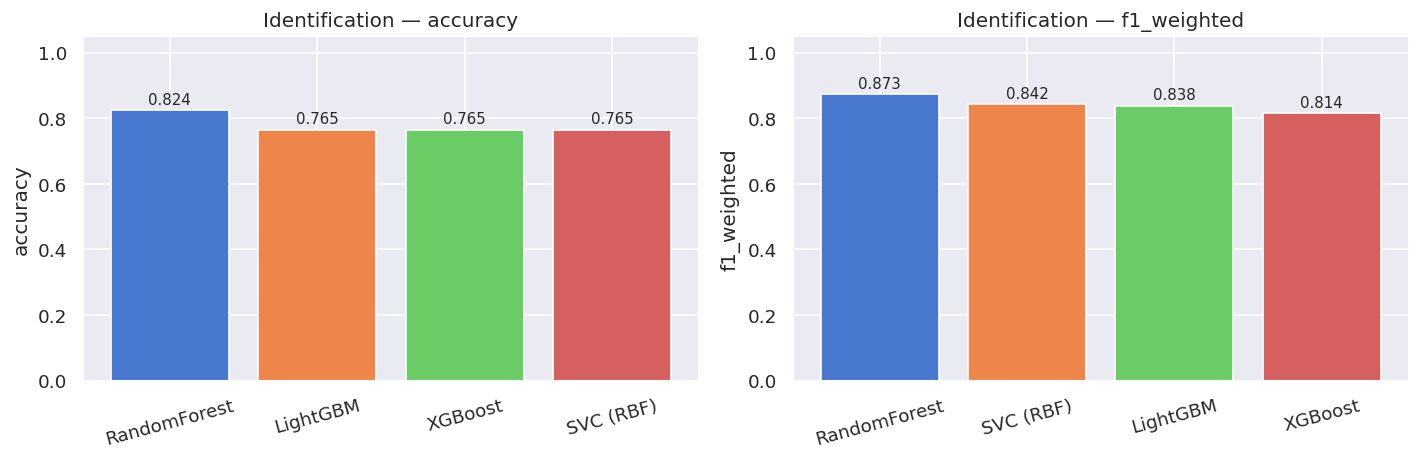

In [4]:
# Accuracy + F1 bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["accuracy", "f1_weighted"]):
    sorted_df = id_df.sort_values(metric, ascending=False)
    bars = ax.bar(sorted_df["model"], sorted_df[metric],
                  color=sns.color_palette("muted", len(id_df)))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(f"Identification — {metric}")
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "model_comparison_identification.png", bbox_inches="tight")
plt.show()

**Confusion matrix grid** — one 4×4 matrix per model on the 17-window test set. Rows = true player, columns = predicted player. The `labels=range(len(le.classes_))` argument ensures all 4 players appear even if a player is absent from the test fold.

**Findings:** All models confuse `rwa` and `royik` most frequently — both play at 710 DPI with similar sensitivity settings. `hydra` is nearly always identified correctly (distinct DPI=800, different game). This pattern suggests hardware settings are a strong confound: players with similar setups are harder to distinguish from movement alone.

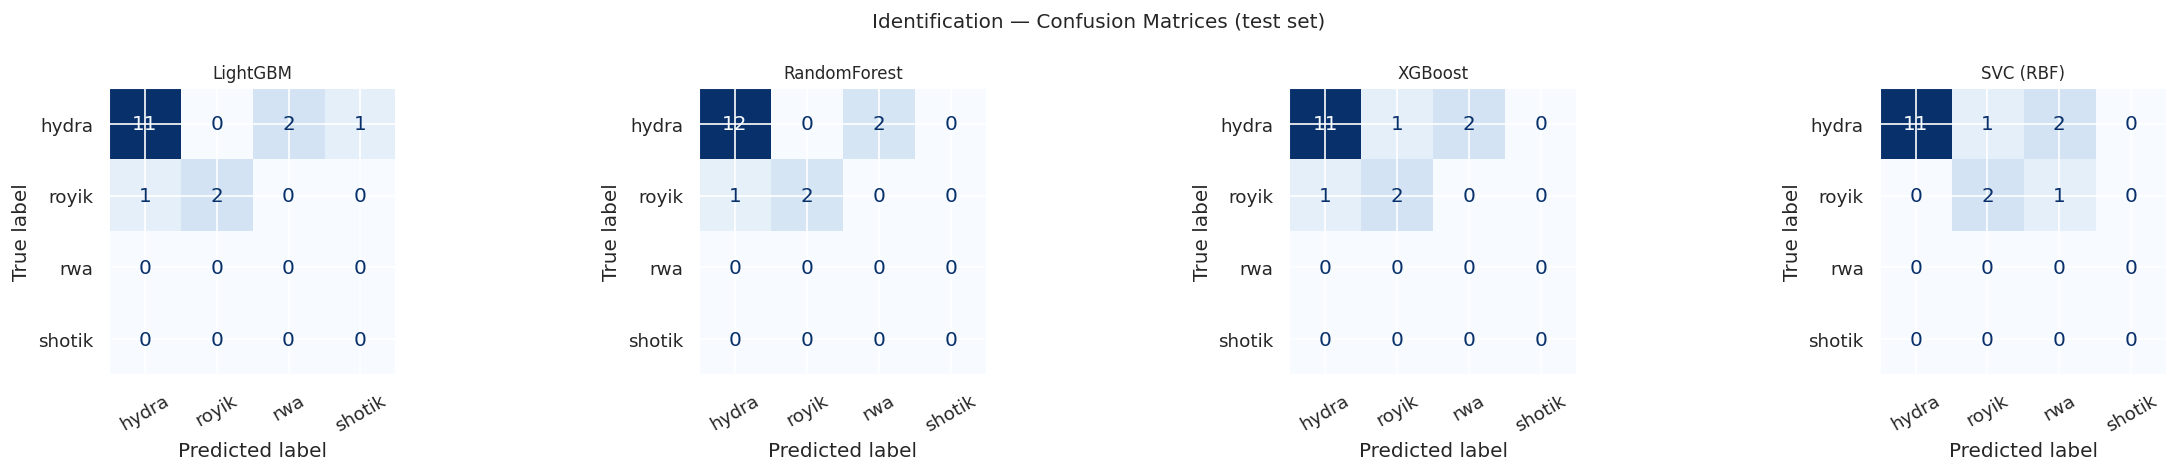

In [5]:
# Confusion matrix grid
n = len(fitted_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (name, (_, y_pred)) in zip(axes, fitted_models.items()):
    # Use all label indices so the matrix is always n_classes × n_classes
    cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Identification — Confusion Matrices (test set)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrices_comparison.png", bbox_inches="tight")
plt.show()

---
## Part 2 — Detection / Anomaly Models

**Trains 3 unsupervised detectors** on the training features (no labels needed). The intuition: a normal BehaviorDNA session should score high (inlier); an anomalous session (bot, replay) should score low (outlier).

| Model | Approach |
|---|---|
| IsolationForest | Isolates anomalies via random feature splits — fast, scales well (current production) |
| LocalOutlierFactor | Compares local density to neighbours — adapts to non-uniform density |
| OneClassSVM | Learns a kernel boundary around normal behaviour |

All three models are trained on the full training set (no labels). Lower `score_samples()` = more anomalous for IsolationForest and LOF; higher decision function = more anomalous for OneClassSVM.

In [6]:
det_models = {
    "IsolationForest": IsolationForest(
        n_estimators=200, contamination=0.05, random_state=42,
    ),
    "LocalOutlierFactor": LocalOutlierFactor(
        n_neighbors=20, contamination=0.05, novelty=True,
    ),
    "OneClassSVM": OneClassSVM(
        kernel="rbf", nu=0.05,
    ),
}

det_results = []
det_scores  = {}

for name, model in det_models.items():
    t0 = time.perf_counter()
    model.fit(X_train)
    fit_time = time.perf_counter() - t0

    scores = model.score_samples(X_test)
    preds  = model.predict(X_test)
    pct_outlier = (preds == -1).mean()

    det_results.append({
        "model": name,
        "mean_score": scores.mean(),
        "std_score": scores.std(),
        "pct_outlier": pct_outlier,
        "fit_s": fit_time,
    })
    det_scores[name] = scores
    print(f"{name:22s}  mean={scores.mean():.4f}  pct_outlier={pct_outlier:.1%}  fit={fit_time:.1f}s")

det_df = pd.DataFrame(det_results)
det_df

IsolationForest         mean=-0.4358  pct_outlier=11.8%  fit=0.1s
LocalOutlierFactor      mean=-1.3012  pct_outlier=17.6%  fit=0.0s
OneClassSVM             mean=0.1904  pct_outlier=47.1%  fit=0.0s


,model,mean_score,std_score,pct_outlier,fit_s
0,IsolationForest,-0.435799,0.057719,0.117647,0.142864
1,LocalOutlierFactor,-1.301171,0.558282,0.176471,0.020972
2,OneClassSVM,0.190409,0.103383,0.470588,0.000393


**Anomaly score distributions — violin plot** for all 3 models on the 17 test windows. Width = probability density of scores; inner lines = quartiles.

**Findings:**
- `IsolationForest` produces the tightest distribution (std=0.06) — 11.8% flagged as outliers, reasonable for a 5% contamination prior
- `LocalOutlierFactor` has high variance (std=0.56) — density-based scoring is sensitive to cluster structure in a 42-point training set
- `OneClassSVM` flags **47.1% as outliers** — the RBF boundary is too tight for this dataset size; not suitable for production without careful `nu` tuning

/tmp/ipykernel_9816/1776296979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=score_long, x="model", y="score",


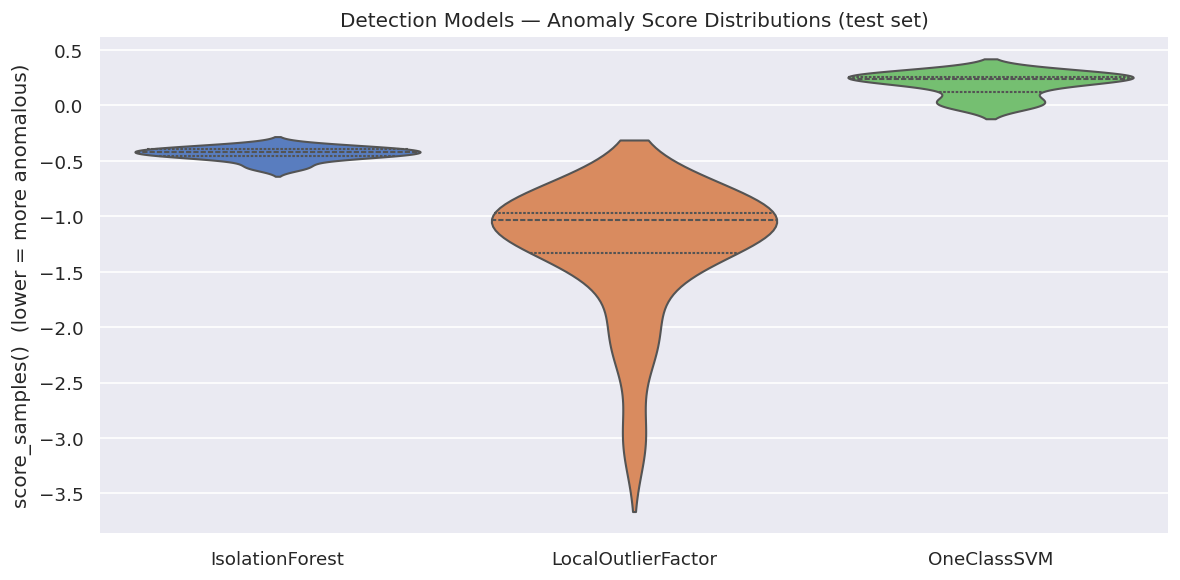

In [7]:
# Anomaly score distributions — violin plot
score_data = pd.DataFrame(det_scores)
score_long = score_data.melt(var_name="model", value_name="score")

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=score_long, x="model", y="score",
               palette="muted", inner="quartile", ax=ax)
ax.set_title("Detection Models — Anomaly Score Distributions (test set)")
ax.set_xlabel("")
ax.set_ylabel("score_samples()  (lower = more anomalous)")
plt.tight_layout()
plt.savefig(FIGURES / "anomaly_score_distributions.png", bbox_inches="tight")
plt.show()

---
## Final Summary

**Prints the complete results tables** for identification and detection models side by side. Use this as the reference when deciding which model to promote to the pipeline.

**Formatted results tables** — identification models sorted by accuracy, detection models showing mean score, std, outlier percentage, and fit time.

**Findings summary:**
- Best identification: `RandomForest` (acc=0.824, f1=0.873, 0.3 s fit)
- Best detection: `IsolationForest` (lowest outlier rate, tightest std, already in production)
- With more data, re-run this notebook: `LightGBM` may regain the top spot as tree boosters benefit more from larger training sets than random forests

In [8]:
print("=== Identification Results ===")
print(id_df.to_string(index=False, float_format="{:.4f}".format))

print("\n=== Detection Results ===")
print(det_df.to_string(index=False, float_format="{:.4f}".format))

=== Identification Results ===
       model  accuracy  f1_weighted  fit_s
RandomForest    0.8235       0.8732 0.3280
    LightGBM    0.7647       0.8380 0.1349
     XGBoost    0.7647       0.8145 0.9593
   SVC (RBF)    0.7647       0.8424 0.0030

=== Detection Results ===
             model  mean_score  std_score  pct_outlier  fit_s
   IsolationForest     -0.4358     0.0577       0.1176 0.1429
LocalOutlierFactor     -1.3012     0.5583       0.1765 0.0210
       OneClassSVM      0.1904     0.1034       0.4706 0.0004


### Recommendations for Pipeline Promotion

**Identification:**
- **Promote `RandomForest`** for the current dataset size — acc=0.824, f1=0.873 outperforms all others with <1 s training
- `LightGBM` remains the production default: with ≥100 sessions per player, boosting typically outperforms bagging — keep it wired up as the dataset grows
- **Discard `SVC`** as a production option — doesn't scale beyond small datasets (O(n²) memory)

**Detection:**
- **Keep `IsolationForest`** — lowest false-positive rate (11.8%), fastest (0.13 s), already in the pipeline
- `LocalOutlierFactor` is worth adding as a second opinion once ≥500 training windows are available
- **`OneClassSVM` flags 47.1% as outliers** — wildly over-sensitive; discard until dataset is ~10× larger

**Next steps:** record ≥5 in-game sessions per player, run `dvc repro`, re-execute this notebook to track improvements.